In [1]:
import numpy as np
import sys
sys.path.append('./diting')
import gemini_models as models

/opt/zb/miniconda3/envs/dtbf_zb/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Please 'pip install apex'
Please 'pip install xformers'
Please 'pip install apex'
Please 'pip install xformers'


In [2]:
import obspy
import torch
import os
import json
import yaml
from diting.downstream.gemini_utils import get_args as get_args_diting
import gemini_util_light as util
import loader_light as loader
from torch.utils.data import DataLoader
import gemini_models as models
import matplotlib.pyplot as plt

In [3]:
config_path = './pga_configs/transformer_italy_plain_ensemble.json'
diting_config_path = './diting/config/conf_reg.yml'

In [4]:
config = json.load(open(config_path, 'r'))

In [5]:
diting_args, ds_init = get_args_diting()
with open(diting_args.conf_file, 'r') as f:
    diting_conf_data = yaml.safe_load(f)
vars(diting_args).update(diting_conf_data)

In [6]:
depth = 24
if depth % diting_args.num_interactions != 0:
    diting_args.num_interactions -= 1
n = (depth - 1)//diting_args.num_interactions
diting_args.interaction_indexes = [[i*n, (i+1)*n] for i in range(diting_args.num_interactions)]
if diting_args.num_interactions * n != depth:
    diting_args.interaction_indexes.append([diting_args.num_interactions*n, depth])

In [7]:
is_dist, rank, world_size, local_rank = util.setup_distributed()

In [8]:
device = 'cuda:3'

In [9]:
training_params = config['training_params']

In [10]:
generator_params = training_params.get('generator_params', [training_params.copy()])

In [11]:
key = generator_params[0].get('key', 'MA')
pos_offset = generator_params[0].get('pos_offset', (-21, -69))
pga_key = generator_params[0].get('pga_key', 'pga')
no_event_token = config['model_params'].get('no_event_token', False)


In [12]:
experiment_path = 'experiment'
suffix = ''
output_dir = os.path.join(experiment_path, f'evaluation{suffix}', 'test')
test_set = True
# if not os.path.isdir(os.path.join(experiment_path, f'evaluation{suffix}')):
#     os.mkdirs(os.path.join(experiment_path, f'evaluation{suffix}'))
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)


In [13]:
if not isinstance(training_params['data_path'], list):
    training_params['data_path'] = [training_params['data_path']]
overwrite_sampling_rate = training_params.get('overwrite_sampling_rate', None)


In [14]:
limit = 300

In [15]:
full_data_train = [loader.load_events(data_path, event_metadata_path='train_ev.csv',limit=limit,
                                      parts=(True, False, False),
                                      shuffle_train_dev=generator.get('shuffle_train_dev', False),
                                      custom_split=generator.get('custom_split', None),
                                      min_mag=generator.get('min_mag', None),
                                      mag_key=generator.get('key', 'MA'),
                                      overwrite_sampling_rate=overwrite_sampling_rate,
                                      decimate_events=generator.get('decimate_events', None))
                   for data_path, generator in zip(training_params['data_path'], generator_params)]

In [16]:
full_data_dev = [loader.load_events(data_path, event_metadata_path='test_ev.csv',limit=limit,
                                    parts=(False, True, False),
                                    shuffle_train_dev=generator.get('shuffle_train_dev', False),
                                    custom_split=generator.get('custom_split', None),
                                    min_mag=generator.get('min_mag', None),
                                    mag_key=generator.get('key', 'MA'),
                                    overwrite_sampling_rate=overwrite_sampling_rate,
                                    decimate_events=generator.get('decimate_events', None))
                 for data_path, generator in zip(training_params['data_path'], generator_params)]


In [17]:
event_metadata_train = [d[0] for d in full_data_train]
metadata_train = [d[2] for d in full_data_train]
event_metadata_dev = [d[0] for d in full_data_dev]
metadata_dev = [d[2] for d in full_data_dev]

sampling_rate = metadata_train[0]['sampling_rate']


In [18]:
max_stations = config['model_params']['max_stations']

config['model_params']['n_datasets'] = len(metadata_train)

ensemble = config.get('ensemble', 1)

super_config = config.copy()
super_training_params = training_params.copy()
super_model_params = config['model_params'].copy()


In [19]:
config['model_params']

{'waveform_model_dims': [500, 500, 500],
 'output_mlp_dims': [150, 10],
 'output_location_dims': [150, 50],
 'wavelength': [[0.01, 15], [0.01, 15], [0.01, 10]],
 'mad_params': {'n_heads': 10, 'att_dropout': 0.0, 'initializer_range': 0.02},
 'ffn_params': {'hidden_dim': 1000},
 'transformer_layers': 6,
 'hidden_dropout': 0.0,
 'activation': 'relu',
 'n_pga_targets': 15,
 'location_mixture': 15,
 'pga_mixture': 5,
 'magnitude_mixture': 5,
 'borehole': False,
 'max_stations': 25,
 'bias_mag_mu': 3.5,
 'bias_mag_sigma': 0.5,
 'bias_loc_mu': 0,
 'bias_loc_sigma': 2,
 'event_token_init_range': 0.02,
 'no_event_token': False,
 'rotation_anchor': [42, 0],
 'n_datasets': 1}

In [20]:
ens_id = 0
# config = super_config.copy()
# config['ens_id'] = ens_id
# training_params = super_training_params.copy()
# training_params['weight_path'] = os.path.join(training_params['weight_path'], f'{ens_id}')
# config['training_params'] = training_params
# config['model_params'] = super_model_params.copy()

# if training_params.get('ensemble_rotation', False):
#     # Rotated by angles between 0 and pi/4
#     config['model_params']['rotation'] = np.pi / 4 * ens_id / (ensemble - 1)


In [21]:
single_station_model, full_model = models.build_transformer_model(**config['model_params'],
#                                                                          trace_length=data_train[0]['waveforms'][0].shape[1],
                                                                  trace_length=10000,
                                                                  diting_args=diting_args
)

[linear_probe/none]Trainable parameters: 5682863
[linear_probe/none]Trainable parameters: 6272687
Sequential(
  (0): ViTAdapter(
    (backbone): PatchTSTEncoder(
      (W_p): Conv1d(3, 512, kernel_size=(50,), stride=(50,))
      (dropout): Dropout(p=0.0, inplace=False)
      (encoder): TSTEncoder(
        (layers): ModuleList(
          (0-23): 24 x TSTEncoderLayer(
            (self_attn): MultiheadAttention_ROPE(
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (o_proj): Linear(in_features=512, out_features=512, bias=True)
              (rotary_emb): LlamaRotaryEmbedding()
              (sdp_attn): ScaledDotProductAttention(
                (attn_dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (drop_path1): Identity()
            (norm_attn): LlamaRMSNorm()


ValueError: Unsupported nonlinearity <function sigmoid at 0x2bab0a4463b0>

In [ ]:
full_model.to(device)

In [ ]:
i = 0
generator_param_set = generator_params[i]
# sampling_rate
noise_seconds = generator_param_set.get('noise_seconds', 5)
cutout = ( sampling_rate * (noise_seconds + generator_param_set['cutout_start']),
           sampling_rate * (noise_seconds + generator_param_set['cutout_end']) )  
n_pga_targets = config['model_params'].get('n_pga_targets', 0)
train_generators = [util.PreloadedEventGenerator(event_metadata=event_metadata_train[i],
                                                  metadata=metadata_train[i],
                                                  data_path=training_params['data_path'][i],
                                                  generator_params=generator_params[i],
                                                  coords_target=True,
                                                  label_smoothing=True,
                                                  station_blinding=True,
                                                  cutout=cutout,
                                                  pga_targets=n_pga_targets,
                                                  max_stations=max_stations,
                                                  sampling_rate=sampling_rate,
                                                  no_event_token=no_event_token,
                                                  **generator_param_set)]

old_oversample = generator_param_set.get('oversample', 1)
generator_param_set['oversample'] = 4
validation_generators = [util.PreloadedEventGenerator(event_metadata=event_metadata_dev[i],
                                                       metadata=metadata_dev[i],
                                                       data_path=training_params['data_path'][i],
                                                       generator_params=generator_params[i],
                                                       coords_target=True,
                                                       station_blinding=True,
                                                       cutout=cutout,
                                                       pga_targets=n_pga_targets,
                                                       max_stations=max_stations,
                                                       sampling_rate=sampling_rate,
                                                       no_event_token=no_event_token,
                                                       **generator_param_set)]
generator_param_set['oversample'] = old_oversample

if len(train_generators) == 0:
    train_dataset = train_generators[0]
    val_dataset = validation_generators[0]
else:
    dataset_bias = config['model_params'].get('dataset_bias', False)
    train_dataset = util.JointGenerator(train_generators, shuffle=True, dataset_id=dataset_bias)
    val_dataset = util.JointGenerator(validation_generators, shuffle=True, dataset_id=dataset_bias)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=generator_params[0]['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=generator_params[0]['batch_size'], shuffle=True)

In [ ]:
def simu_forward(model, waveform_inp, metadata_inp, pga_targets_inp=None,dataset=None, att_mask=None):
    with torch.no_grad():
        waveforms_masked = model.Masking_nd_0_23(waveform_inp)
        coords_masked = model.Masking_nd_0_2(metadata_inp)
        print('waveforms_masked: ',waveforms_masked)
        print('coords_masked: ', coords_masked)
        waveforms_emb = torch.stack([model.waveform_model(waveforms_masked[:, i, :, :]) for i in range(waveforms_masked.shape[1])] , dim=1)
        print(f'waveforms_emb(shape:{waveforms_emb.shape}): ',waveforms_emb)
        waveforms_emb = model.layernorm(waveforms_emb)        

        if not model.alternative_coords_embedding:
            coords_emb = model.position_embedding(coords_masked)
            print(f'norm of waveforms_emb: {torch.norm(waveforms_emb, dim=-1)}')
            print(f'norm of coords_emb: {torch.norm(coords_emb, dim=-1)}')
            emb = waveforms_emb + coords_emb
            print(f'coords_emb (shape: {coords_emb.shape}): ', coords_emb)
        else:
            emb = torch.cat([waveforms_emb, coords_masked], dim=-1)

        if not (model.skip_transformer or model.no_event_token):
            emb = model.add_event_token(emb)
            print(f'add event token(shape: {emb.shape}): ',emb)

        if model.n_pga_targets:
            pga_targets_masked = model.Masking_nd_0_2(pga_targets_inp)
            pga_emb = model.position_embedding(pga_targets_masked)
            emb = torch.cat([emb, pga_emb], dim=1)
            print(f'pga_pos_emb (shape: {pga_emb.shape}): ', pga_emb)

            if att_mask is None:
                # Create an attention mask based on the shape of emb
#                att_mask = torch.cat([torch.ones_like(emb[:, :emb.shape[1] - pga_emb.shape[1], 0], dtype=torch.bool),
#                                       torch.zeros_like(emb[:, emb.shape[1] - pga_emb.shape[1]:, 0], dtype=torch.bool)], dim=1)
                att_mask = model.Masking_nd_0_23.compute_mask(waveform_inp)
                att_mask = torch.cat([att_mask,
                                      torch.zeros_like(emb[:, emb.shape[1] - pga_emb.shape[1]:, 0], dtype=torch.bool)], dim=1)
                
                if not (model.skip_transformer or model.no_event_token):
                    att_mask = torch.cat([torch.ones_like(emb[:, :1, 0], dtype=torch.bool), att_mask], dim=1)
                print('att_mask: ', att_mask)
            emb = model.transformer(emb.float(), att_mask) # Modified line
        else:
            if model.skip_transformer:
                emb = torch.stack([model.mlp_layer(emb[:, i, :]) for i in range(emb.shape[1])], dim=1)
                emb = model.maxpool(emb, mask=coords_masked[:,:,0] != 0)
            else:
                emb = model.transformer(emb.float())
                print('transformer output: ', emb)

        outputs = []
        if not model.no_event_token:
            if model.skip_transformer:
                event_emb = emb
            else:
                event_emb = emb[:, 0, :]  # Select event embedding

            mag_embedding = model.mlp_mag(event_emb)
            #out_mag = model.output_model_mag(mag_embedding)
            alpha_logits, mu, sigma = model.output_model_mag(mag_embedding)
            mu = mu * 10
            out_mag = torch.cat([alpha_logits, mu, sigma], dim=-1)  # (batch, n, 1+d+d)

            loc_embedding = model.mlp_loc(event_emb)
            #out_loc = model.output_model_loc(loc_embedding)
            alpha_logits, mu, sigma = model.output_model_loc(loc_embedding)
            out_loc = torch.cat([alpha_logits, mu, sigma], dim=-1)  # (batch, n, 1+d+d)

            outputs.append(out_mag)
            outputs.append(out_loc)

        if model.n_pga_targets:
            pga_emb = emb[:, -model.n_pga_targets:, :]  # Select embeddings for pga
            pga_emb_tmp = []
            for i in range(pga_emb.shape[1]):
                mlp_pga_out = model.mlp_pga(pga_emb[:, i, :])
                pga_emb_tmp.append(mlp_pga_out)
                print('mlp_pga input: ', pga_emb[:,i,:])
                print('mlp_pga output: ', mlp_pga_out)
                
            pga_emb = torch.stack(pga_emb_tmp, dim=1)
            #output_pga = torch.stack([model.output_model_pga(pga_emb[:, i, :]) for i in range(pga_emb.shape[1])], dim=1)
            pga_out_tmp = []
            for i in range(pga_emb.shape[1]):
                alpha_logits, mu, sigma = model.output_model_pga(pga_emb[:, i, :])
                pga_out_tmp.append(torch.cat([alpha_logits, mu, sigma], dim=-1))
                print('use pga emb: ', pga_emb[:, i, :])
                print('get pga_out: ', torch.cat([alpha_logits, mu, sigma], dim=-1))
            output_pga = torch.stack(pga_out_tmp, dim=1)
            outputs.append(output_pga)

        if model.dataset_bias:
            assert model.n_datasets is not None
            dataset_bias_term = model.dataset_embedding(dataset).squeeze(-1)
            out = model.add_constant_to_mixture()(out, dataset_bias_term)

        return outputs


In [ ]:
train_iter = iter(train_loader)

In [ ]:
inputs, labels, picks = next(train_iter)
if isinstance(inputs, list):
    inputs, labels = [i.to(device) for i in inputs], [l.to(device) for l in labels]
else:
    inputs, labels = inputs.to(device), labels.to(device)

In [ ]:
bch1, sta1 = 0, 0
bch2, sta2 = 0, 1
tmp_waveform = torch.cat([inputs[0][bch1:bch1+1,sta1:sta1+1], inputs[0][bch2:bch2+1,sta2:sta2+1]], dim=1)
tmp_sta = torch.cat([inputs[1][bch1:bch1+1,sta1:sta1+1], inputs[1][bch2:bch2+1,sta2:sta2+1]], dim=1)
tmp_pga_sta = torch.cat([inputs[2][bch1:bch1+1,sta1:sta1+1], inputs[2][bch2:bch2+1,sta2:sta2+1]], dim=1)

In [ ]:

def detach_output(output):
    if torch.is_tensor(output):
        return output.detach()
    elif isinstance(output, (tuple, list)):
        return type(output)(detach_output(o) for o in output)
    elif isinstance(output, dict):
        return {k: detach_output(v) for k, v in output.items()}
    else:
        return output  # 其他类型保持原样
def get_hook(name):
    def hook(module, input, output):
        activations[name] = detach_output(output)
    return hook        
handles = []    
for name, module in full_model.named_modules():
    if name.startswith('waveform_model.'):
        continue
    h = module.register_forward_hook(get_hook(name))
    handles.append(h)


In [ ]:
for h in handles:
    h.remove()

In [ ]:
activations = {}

# xx = full_model(torch.rand(1,2,3,10000).to(device),torch.rand(1,2,3).to(device),torch.rand(1,2,3).to(device))
# xx = simu_forward(full_model, inputs[0][:1,:2],inputs[1][:1,:2],inputs[2][:1,:2])
# xx = simu_forward(full_model,torch.rand(1,2,3,10000).to(device),torch.rand(1,2,3).to(device),torch.rand(1,2,3).to(device))
xx = simu_forward(full_model, tmp_waveform, tmp_sta, tmp_pga_sta)

In [ ]:
xx

In [ ]:
full_model.output_model_pga

In [96]:
output_model_pga = torch.nn.Linear(10,5)
torch.nn.init.xavier_uniform_(output_model_pga.weight)
torch.nn.init.zeros_(output_model_pga.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0.], requires_grad=True)

In [127]:

torch.nn.init.kaiming_normal_(output_model_pga.weight,nonlinearity='relu')

Parameter containing:
tensor([[-0.1087, -0.2891, -0.1022,  0.1664, -1.0167, -0.0595, -0.5127,  0.1408,
          1.0069, -0.1704],
        [-0.1531,  1.0999,  0.1899, -0.7549,  0.7825, -0.5839, -0.0118, -0.0446,
         -0.1646, -0.5959],
        [ 0.2658,  0.3440, -0.0896, -0.0173, -0.2523, -0.8387,  0.3848,  0.5052,
          0.1253, -0.1542],
        [-0.4383,  0.1672,  0.4540, -0.4105,  0.2216,  0.2468, -0.1513,  0.2994,
         -0.1262, -0.3596],
        [-0.1401,  0.5874, -0.5767, -0.4428, -0.2216, -0.3251,  0.2669,  0.8760,
          0.5734,  0.1512]], requires_grad=True)

In [123]:
with torch.no_grad():
    res_tmp = output_model_pga(torch.rand(5,10))
    print(res_tmp)

tensor([[ 0.4664,  1.0993, -0.9266,  0.4167,  1.2250],
        [ 0.0326,  0.2723,  0.1736, -0.0903,  0.3454],
        [ 0.0795,  0.5187, -0.2022,  0.1478,  0.4362],
        [ 0.0245,  0.6529,  0.2352,  0.2830,  0.4474],
        [ 0.4707,  0.3781, -0.7560, -0.0062,  0.8874]])


In [86]:
full_model.output_model_pga(torch.rand(5,10).to(device))

(tensor([[[-0.0552],
          [-0.3498],
          [-0.4487],
          [ 0.4137],
          [ 0.3397]],
 
         [[-0.1869],
          [ 0.1932],
          [ 0.1015],
          [ 0.5035],
          [-0.3322]],
 
         [[-0.1898],
          [-0.4309],
          [-0.0020],
          [ 0.5064],
          [ 0.1388]],
 
         [[-0.7369],
          [-0.2060],
          [ 0.6225],
          [ 0.3985],
          [-0.0336]],
 
         [[-0.2118],
          [ 0.4016],
          [ 0.0694],
          [ 0.3021],
          [-0.0591]]], device='cuda:3', grad_fn=<UnsqueezeBackward0>),
 tensor([[[-0.0856],
          [ 0.0307],
          [-0.4846],
          [ 0.0332],
          [-0.4682]],
 
         [[-0.3758],
          [-0.2747],
          [-0.1165],
          [-0.3258],
          [-0.6500]],
 
         [[-0.1031],
          [ 0.0023],
          [-0.4301],
          [-0.1390],
          [-0.4384]],
 
         [[-0.3262],
          [ 0.3201],
          [-0.2832],
          [-0.2936],
     

In [163]:
full_model.mlp_pga(torch.rand(1,2,500).to(device))

tensor([[[ 0.1442,  0.1528,  0.1254, -0.0791,  0.0645,  0.0823, -0.1834,
          -0.1230, -0.0748,  0.1795],
         [ 0.1387,  0.1565,  0.1247, -0.0784,  0.0658,  0.0778, -0.1803,
          -0.1141, -0.0702,  0.1752]]], device='cuda:3',
       grad_fn=<ViewBackward0>)

In [165]:
# 看看存下来的每一层输出
for name, tensor in activations.items():
    # if isinstance(tensor, torch.Tensor):
    #     # tensor = tensor.squeeze()
    #     print(name,tensor)
    if name.startswith('mlp_pga'):
        print(name, tensor)
    # if isinstance(tensor, torch.Tensor):
    #     print(name, tensor.shape)

mlp_pga.mlp.0 tensor([[ 0.3201, -0.8011, -0.3460, -0.6032, -0.0110,  0.0856, -0.0094,  0.0717,
          0.0662, -0.0858,  0.3084,  0.4128,  0.6261, -0.4276,  0.0028, -0.2391,
          0.2095, -0.2931,  0.4752, -0.1104,  0.6184,  0.1333,  0.3527,  0.5056,
         -0.6231, -0.4049, -0.5500, -0.3583, -0.5277, -0.0924, -0.4170, -0.3369,
          0.0349,  0.2405, -0.2194,  0.4921, -0.3639, -0.2003,  0.0879,  0.2692,
          0.1601, -0.0393, -0.1769, -0.2620,  0.3025, -0.0177,  0.4102, -0.4382,
         -0.0970,  0.4780, -0.2165, -0.1036, -0.0099,  0.0723, -0.3125,  0.2396,
         -0.1546, -0.1712, -0.0789,  0.7660, -0.0356, -0.2082, -0.4642, -0.2179,
         -0.0932, -0.1281,  0.0766,  0.2936,  0.0944, -0.1911,  0.6092,  0.1695,
         -0.4492, -0.0478,  0.2739,  0.3718,  0.1207,  0.2851, -0.0577,  0.4596,
          0.1731,  0.0826,  0.3632,  0.2094, -0.2900,  0.8311,  0.3783,  0.1859,
         -0.2191,  0.1862, -1.1159,  0.5529, -0.1116,  0.3292, -0.4738, -0.3062,
          0.42

In [171]:
full_model.mlp_pga

MLP(
  (mlp): Sequential(
    (0): Linear(in_features=500, out_features=150, bias=True)
    (1): ReLU()
    (2): Linear(in_features=150, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=30, bias=True)
    (7): ReLU()
    (8): Linear(in_features=30, out_features=10, bias=True)
  )
)

In [168]:
from gemini_models import MLP

In [172]:
mlp = MLP(input_shape=(500,), dims=[150,100,50,30, 10], activation='relu', use_layernorm=False, use_batchnorm=False)

x1 = torch.randn(4, 500)
x2 = torch.randn(4, 500)

y1 = mlp(x1)
y2 = mlp(x2)

print("x1 std:", x1.std().item())
print("x2 std:", x2.std().item())
print("y1 std:", y1.std().item())
print("y2 std:", y2.std().item())
print("mean |y1 - y2|:", (y1 - y2).abs().mean().item())
print("max  |y1 - y2|:", (y1 - y2).abs().max().item())

x1 std: 1.0198909044265747
x2 std: 1.0087987184524536
y1 std: 0.12535317242145538
y2 std: 0.12486175447702408
mean |y1 - y2|: 0.010207791812717915
max  |y1 - y2|: 0.02569320797920227


In [177]:
y1

tensor([[-0.0161,  0.0256, -0.1361, -0.1367,  0.0095,  0.1655, -0.2301,  0.0967,
         -0.0990,  0.0817],
        [-0.0114,  0.0116, -0.1443, -0.1453, -0.0036,  0.1933, -0.2289,  0.0900,
         -0.0859,  0.0760],
        [-0.0214,  0.0038, -0.1568, -0.1404,  0.0040,  0.2101, -0.2342,  0.0918,
         -0.0951,  0.0979],
        [-0.0289, -0.0044, -0.1645, -0.1397,  0.0047,  0.2072, -0.2327,  0.0804,
         -0.0833,  0.1035]], grad_fn=<ViewBackward0>)

In [175]:
y2

tensor([[-0.0275,  0.0077, -0.1447, -0.1268,  0.0329,  0.1878, -0.2404,  0.0826,
         -0.0823,  0.0987],
        [-0.0255,  0.0187, -0.1429, -0.1363,  0.0031,  0.1796, -0.2309,  0.0902,
         -0.1005,  0.0928],
        [-0.0223,  0.0090, -0.1425, -0.1385,  0.0071,  0.1844, -0.2399,  0.0972,
         -0.0982,  0.0982],
        [-0.0151,  0.0069, -0.1616, -0.1462,  0.0006,  0.1897, -0.2231,  0.0990,
         -0.0993,  0.0984]], grad_fn=<ViewBackward0>)

In [196]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        dims,
        activation=nn.ReLU(),
        last_activation=None,
        dropout: float = 0.0,
        use_layernorm: bool = False,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        assert not (use_layernorm and use_batchnorm), "LayerNorm 和 BatchNorm 不要同时开"

        if isinstance(dims, int):
            dims = [dims]

        layers = []
        prev_dim = in_dim

        for i, dim in enumerate(dims):
            layers.append(nn.Linear(prev_dim, dim))
            is_last = (i == len(dims) - 1)

            if not is_last:
                if activation is not None:
                    layers.append(activation)
            else:
                if last_activation is not None:
                    layers.append(last_activation)
            if use_batchnorm and not is_last:
                layers.append(nn.BatchNorm1d(dim))

            if dropout > 0 and not is_last:
                layers.append(nn.Dropout(dropout))

            prev_dim = dim

        if use_layernorm:
            layers.append(nn.LayerNorm(prev_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (..., in_dim)
        orig_shape = x.shape
        x = x.view(-1, orig_shape[-1])
        x = self.mlp(x)
        x = x.view(*orig_shape[:-1], -1)
        return x

mlp = MLP(
    in_dim=500,
    dims=[150, 10],
    activation=nn.ReLU(),
    last_activation=None,
    use_layernorm=False,
    use_batchnorm=True,
).eval()

# 两批完全独立的随机输入
x1 = torch.randn(32, 500)
x2 = torch.randn(32, 500)

with torch.no_grad():
    y1 = mlp(x1)
    y2 = mlp(x2)

print("y1 mean/std:", y1.mean().item(), y1.std().item())
print("y2 mean/std:", y2.mean().item(), y2.std().item())
print("mean |y1 - y2|:", (y1 - y2).abs().mean().item())
print("std |y1 - y2|:", (y1 - y2).std().item())
print(mlp)

y1 mean/std: -0.06790263950824738 0.2239953875541687
y2 mean/std: -0.07549028098583221 0.22005127370357513
mean |y1 - y2|: 0.214456707239151
std |y1 - y2|: 0.2689531445503235
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=500, out_features=150, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(150, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=150, out_features=10, bias=True)
  )
)


In [194]:
print(y1)
print(y2)

tensor([[-9.6673e-03, -1.4816e-01, -1.4023e-01,  1.1536e-01, -9.4125e-02,
          1.2378e-01, -1.3386e-01,  1.0644e-01, -1.4072e-01, -9.4743e-02],
        [-7.5035e-03, -1.6995e-01, -1.4743e-01,  1.0448e-01, -1.1187e-01,
          1.3618e-01, -1.4969e-01,  9.8681e-02, -1.3898e-01, -7.8803e-02],
        [-2.7541e-02, -1.3696e-01, -1.3599e-01,  1.1397e-01, -7.7939e-02,
          1.4674e-01, -1.4041e-01,  1.2123e-01, -1.1334e-01, -6.9587e-02],
        [-1.6051e-02, -1.5377e-01, -1.4513e-01,  1.0865e-01, -9.0351e-02,
          1.5671e-01, -1.4211e-01,  9.9354e-02, -1.4625e-01, -8.0185e-02],
        [ 4.4978e-03, -1.8022e-01, -1.5590e-01,  1.0790e-01, -9.3164e-02,
          1.5589e-01, -1.5693e-01,  1.0244e-01, -1.6756e-01, -8.4294e-02],
        [-2.0290e-02, -1.7062e-01, -1.4519e-01,  9.8241e-02, -9.2837e-02,
          1.6652e-01, -1.4846e-01,  1.1356e-01, -1.5043e-01, -8.5150e-02],
        [-2.7522e-02, -1.6451e-01, -1.7636e-01,  9.9618e-02, -7.7843e-02,
          1.5773e-01, -1.4328e-0

In [57]:
xx = simu_forward(full_model, inputs[0][:1,:2],inputs[1][:1,:2],inputs[2][:1,:2])

waveforms_masked:  tensor([[[[ 4.3526e-01,  3.4505e-01,  3.0860e-01,  ..., -1.3678e-17,
           -1.3678e-17, -1.3678e-17],
          [ 6.3575e-01,  6.4632e-01,  3.7088e-01,  ...,  1.2244e-16,
            1.2244e-16,  1.2244e-16],
          [ 6.6128e-01,  1.8865e-01,  3.3037e-02,  ...,  1.6431e-17,
            1.6431e-17,  1.6431e-17]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]]]], device='cuda:3')
coords_masked:  tensor([[[43.9860, -4.4468, -0.5950],
         [ 0.0000,  0.0000,  0.0000]]], device='cuda:3')
waveforms_emb(shape:torch.Size([1, 2, 500])):  tensor([[[-0.1288,  0.7160, -0.0589,  0.1065,  0.1016, -0.6484, -1.1113,
          -0.9576, -0.2839,  0.1850,  0.6098,  0.4216, -1.2483,  0.4723,
          -0.

In [30]:
xx = simu_forward(full_model, inputs[0],inputs[1],inputs[2])

waveforms_masked:  tensor([[[[ 4.3526e-01,  3.4505e-01,  3.0860e-01,  ..., -1.3678e-17,
           -1.3678e-17, -1.3678e-17],
          [ 6.3575e-01,  6.4632e-01,  3.7088e-01,  ...,  1.2244e-16,
            1.2244e-16,  1.2244e-16],
          [ 6.6128e-01,  1.8865e-01,  3.3037e-02,  ...,  1.6431e-17,
            1.6431e-17,  1.6431e-17]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         ...

In [36]:
waveform_inp = inputs[0]
metadata_inp = inputs[1]
model = full_model
with torch.no_grad():
    waveforms_masked = model.Masking_nd_0_23(waveform_inp)
    coords_masked = model.Masking_nd_0_2(metadata_inp)
    print('waveforms_masked: ',waveforms_masked)
    print('coords_masked: ', coords_masked)
    waveforms_emb = torch.stack([model.waveform_model(waveforms_masked[:, i, :, :]) for i in range(waveforms_masked.shape[1])] , dim=1)
#    waveforms_emb = model.layernorm(waveforms_emb)

waveforms_masked:  tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         ...

In [65]:
waveforms_emb.shape

torch.Size([32, 25, 500])

In [73]:
inputs[0][0,0]

tensor([[-1.3618, -2.2864,  1.3660,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1333,  1.4131, -1.1546,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.5644,  1.6307, -0.5815,  ...,  0.0000,  0.0000,  0.0000]],
       device='cuda:3')

In [76]:
inputs[0][1,0]

tensor([[ 0.0594,  0.1670, -0.0476,  ...,  0.0000,  0.0000,  0.0000],
        [-0.2315,  0.0279,  0.0798,  ...,  0.0000,  0.0000,  0.0000],
        [-0.2651, -0.0468,  0.0734,  ...,  0.0000,  0.0000,  0.0000]],
       device='cuda:3')

In [68]:
waveforms_emb[0]

tensor([[ 0.0607,  0.0838, -0.1512,  ..., -0.0691, -0.2573, -0.3754],
        [ 0.0306,  0.0544, -0.1218,  ..., -0.0451, -0.1921, -0.2748],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        ...,
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007]],
       device='cuda:3')

In [66]:
waveforms_emb[1]

tensor([[ 0.0265,  0.0381, -0.1193,  ..., -0.0461, -0.1832, -0.2541],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        ...,
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007],
        [ 0.0078,  0.0363, -0.0990,  ..., -0.0254, -0.1426, -0.2007]],
       device='cuda:3')

In [67]:
(waveforms_emb[1][0] - waveforms_emb[0][1])/(abs(waveforms_emb[0][0]) + 1e-6)

tensor([-6.8918e-02, -1.9514e-01,  1.6795e-02,  3.4044e-02,  9.7403e-02,
         7.2793e-02, -4.6944e-02, -1.2555e-01, -1.0766e-01, -8.8179e-02,
         2.8345e-02, -1.2258e-01, -9.8283e-02, -1.4508e-01, -5.0214e-02,
         8.9983e-02, -5.6032e-03,  1.3055e-01,  2.9395e-02, -5.9961e-02,
         8.0204e-02, -3.6697e-02,  5.1265e-03, -7.1037e-02,  9.2074e-03,
         5.6142e-02, -1.5893e-01,  2.2662e-01, -7.1780e-02, -8.0466e-02,
         1.2335e+01, -6.7832e-02, -3.8481e-02,  5.4540e-02,  2.0712e-02,
        -2.0981e-02, -9.4423e-02,  6.2064e-02, -6.6663e-02,  5.5723e-02,
         4.2170e-02,  6.8128e-02,  4.4517e-02,  9.9910e-02, -1.3526e-01,
         2.2019e-01, -5.0428e-02, -3.4908e-02,  7.7369e-02, -8.5517e-02,
         9.7757e-03, -4.4705e-02,  9.7639e-02,  1.6244e-01, -6.9778e-02,
        -9.4964e-02, -6.9019e-02, -9.3016e-02,  8.1375e-02, -9.3600e-03,
        -3.2248e-01,  2.7705e-02, -6.3036e-02, -8.0858e-02,  7.7157e-02,
        -3.1113e-02,  9.5211e-02,  8.3336e-02,  1.2

In [34]:
with torch.no_grad():
    xx = full_model.transformer(torch.ones(32,25,500).to(device))
    print(xx)

tensor([[[ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         ...,
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637]],

        [[ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         ...,
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637]],

        [[ 1.3165,  0.3172, -0.6822,  ...,  0.1517, -1.8771, -0.1637],
         [ 1.3165,  0.3172, -0.6822,  ...,  0

In [33]:
def mixture_density_loss_full(y_pred, y_true, eps=1e-6, d=1, mean=True, print_shapes=False):
    res_comps = ['mag', 'loc', 'pga']
    res_weight = np.array([1.,1.,1.])
    res_weight = res_weight / np.sum(res_weight)
    loss = 0.
    for i, res_comp in enumerate(res_comps):
        print('res_comp:',res_comp)
        alpha = y_pred[i][..., 0]
        log_density = torch.zeros_like(y_pred[i][..., 0]).to(y_pred[i].device)  # Move to device
            
        if res_comp == 'loc':
            d = 3 
        else:
            d = 1 

        for j in range(d):
            mu = y_pred[i][..., j + 1]
            print('mu:', mu)
            sigma = y_pred[i][..., j + 1 + d]
            sigma = torch.maximum(sigma, torch.tensor(eps).to(y_pred[i].device)) #Move to device
            print('sigma:', sigma)
            y_true_tmp = y_true[i][..., j].clone()
            while y_true_tmp.dim() < sigma.dim():
                y_true_tmp = y_true_tmp.unsqueeze(-1)
            log_density +=  - torch.log(np.sqrt(2 * np.pi) * sigma) - (y_true_tmp - mu) ** 2 / (2 * sigma ** 2)
            print('log_density:', log_density)
        log_density += torch.log(alpha)
        log_density = torch.logsumexp(log_density, dim=-1)
        print('log_density2:', log_density)
        loss -= res_weight[i]*torch.mean(log_density)
    return loss

In [35]:
models.mixture_density_loss_full(outputs, labels)

tensor(134.7733, device='cuda:3')

In [36]:
mean_mag = torch.sum(torch.softmax(outputs[0][:,:,0], dim=-1)*outputs[0][:,:,1], axis=1)

In [37]:
mean_loc = torch.sum(torch.softmax(outputs[1][:,:,0:1], dim=-2) * outputs[1][:,:,1:4], axis=1)

In [38]:
mean_pga = torch.sum(torch.softmax(outputs[2][:,:,:,0],dim=-1)*outputs[2][:,:,:,1], axis=2)

In [43]:
res_comps = ['mag', 'loc', 'pga']
res_weight = np.array([1.,1.,1.])
res_weight = res_weight / np.sum(res_weight)
y_pred = outputs
y_true = labels

In [40]:
for i, res_comp in enumerate(res_comps):
    alpha_logits = y_pred[i][..., 0]
    log_density = torch.zeros_like(y_pred[i][..., 0]).to(y_pred[i].device)  # Move to device
 
    if res_comp == 'loc':
        d = 3
    else:
        d = 1  

    for j in range(d):
        mu = y_pred[i][..., j + 1] 
        sigma = y_pred[i][..., j + 1 + d] 

        y_true_tmp = y_true[i][..., j].clone()
        while y_true_tmp.dim() < sigma.dim():
            y_true_tmp = y_true_tmp.unsqueeze(-1)
        log_density = log_density - torch.log(np.sqrt(2 * np.pi) * sigma) - (y_true_tmp - mu) ** 2 / (2 * sigma ** 2)

    log_density = log_density + torch.log_softmax(alpha_logits,dim=-1)
    log_density = torch.logsumexp(log_density, dim=-1)
    print(f'loss for {res_comp}: {-torch.mean(log_density)}')
    print(f'loss for {res_comp}: {-(log_density)}')
    
    # loss = loss - res_weight[i]*torch.mean(log_density)


loss for mag: 1.9250500202178955
loss for mag: tensor([2.3188, 1.0665, 1.8200, 1.0594, 2.4561, 1.2739, 2.1860, 2.1863, 2.3189,
        2.7442, 2.5982, 1.2739, 2.4563, 1.3444, 1.8201, 1.8201, 1.2165, 1.6070,
        2.4563, 2.5980, 2.7442, 1.3443, 2.5980, 1.0866, 2.7444, 2.1860, 1.9364,
        1.8200, 2.3188, 1.1326, 1.9362, 1.1332], device='cuda:3')
loss for loc: 397.31634521484375
loss for loc: tensor([402.6182, 423.1617, 377.0567, 413.4684, 401.5135, 423.9832, 416.6696,
        424.0300, 354.2083, 386.3025, 396.6561, 420.4895, 426.1554, 413.3872,
        337.7186, 353.4405, 332.8913, 422.6547, 440.2837, 447.2142, 416.0805,
        423.4567, 377.9107, 422.8808, 383.5914, 405.7165, 379.4448, 403.1509,
        370.7880, 338.9176, 439.3783, 338.9040], device='cuda:3')
loss for pga: 5.078397750854492
loss for pga: tensor([[ 5.3282,  5.3282,  5.3282,  5.3282,  5.3282,  5.3282,  5.3282,  5.3282,
          4.4106,  4.4106,  4.4106,  4.4106,  4.4106,  4.4106,  4.4106],
        [ 2.7453,  2.7

In [111]:
log_density = torch.zeros_like(outputs[i][..., 0]).to(outputs[i].device)

In [112]:
j = 0
d = 1
mu = y_pred[i][..., j + 1] 
sigma = y_pred[i][..., j + 1 + d] 

y_true_tmp = y_true[i][..., j].clone()
while y_true_tmp.dim() < sigma.dim():
    y_true_tmp = y_true_tmp.unsqueeze(-1)
log_density +=  - torch.log(np.sqrt(2 * np.pi) * sigma) - (y_true_tmp - mu) ** 2 / (2 * sigma ** 2)


In [42]:
outputs[0]

tensor([[[-0.1306,  5.2645,  1.4913],
         [ 0.2679,  4.6402,  1.2105],
         [-0.2734,  4.9950,  1.1866],
         [-0.1353,  4.5439,  0.7370],
         [-0.2276,  4.7622,  1.2359]],

        [[-0.1306,  5.2646,  1.4911],
         [ 0.2679,  4.6401,  1.2104],
         [-0.2734,  4.9949,  1.1866],
         [-0.1353,  4.5442,  0.7371],
         [-0.2276,  4.7622,  1.2359]],

        [[-0.1306,  5.2645,  1.4913],
         [ 0.2679,  4.6402,  1.2105],
         [-0.2734,  4.9950,  1.1866],
         [-0.1353,  4.5439,  0.7370],
         [-0.2276,  4.7622,  1.2359]],

        [[-0.1305,  5.2658,  1.4908],
         [ 0.2683,  4.6402,  1.2101],
         [-0.2735,  4.9946,  1.1865],
         [-0.1349,  4.5442,  0.7371],
         [-0.2273,  4.7619,  1.2357]],

        [[-0.1306,  5.2644,  1.4914],
         [ 0.2679,  4.6401,  1.2106],
         [-0.2733,  4.9951,  1.1865],
         [-0.1353,  4.5436,  0.7370],
         [-0.2276,  4.7623,  1.2359]],

        [[-0.1306,  5.2651,  1.4909],
  

In [127]:
density_1.shape

torch.Size([32, 5])

In [128]:
torch.softmax(alpha_logits,dim=-1).shape

torch.Size([32, 5])

In [129]:
density_2 = torch.softmax(alpha_logits,dim=-1) * 1/(np.sqrt(2*np.pi)*sigma)*torch.exp(-(mu - y_true_tmp)**2/(2* sigma**2))

In [140]:
density_1 = torch.log(torch.sum(torch.softmax(alpha_logits,dim=-1)*  1/(np.sqrt(2*np.pi)*outputs[0][:,:,2])*torch.exp(-(outputs[0][:,:,1] - labels[0])**2/(2* outputs[0][:,:,2]**2)),dim=-1))

In [137]:
density_0 = torch.logsumexp(log_density + torch.log_softmax(alpha_logits, dim=-1), dim=-1)

In [92]:
labels[0].ravel()

tensor([2.7000, 4.0000, 2.9000, 4.5147, 3.0000, 4.1006, 3.0000, 2.7000, 3.0000,
        2.7000, 2.9000, 2.8000, 3.0000, 3.0000, 2.7000, 2.8000, 3.8000, 4.8591,
        4.7884, 2.8000, 4.0973, 2.9000, 2.9000, 3.0000, 3.4000, 2.7000, 3.1000,
        2.7000, 2.7000, 2.7000, 4.4834, 3.0000], device='cuda:3')

In [142]:
density_0.ravel()

tensor([-0.2122, -1.4517,  0.4035, -1.8937,  0.1886, -1.4977,  0.1886, -0.2122,
         0.1886, -0.2122,  0.4035,  0.2724,  0.1886,  0.1886, -0.2122,  0.2724,
        -1.4264, -2.4309, -2.3079,  0.2724, -1.4959,  0.4035,  0.4035,  0.1886,
        -1.6095, -0.2122, -0.3299, -0.2122, -0.2122, -0.2122, -1.8533,  0.1886],
       device='cuda:3')

In [141]:
density_1

tensor([-0.2122, -1.4517,  0.4035, -1.8937,  0.1886, -1.4977,  0.1886, -0.2122,
         0.1886, -0.2122,  0.4035,  0.2724,  0.1886,  0.1886, -0.2122,  0.2724,
        -1.4264, -2.4309, -2.3079,  0.2724, -1.4959,  0.4035,  0.4035,  0.1886,
        -1.6095, -0.2122, -0.3299, -0.2122, -0.2122, -0.2122, -1.8533,  0.1886],
       device='cuda:3')

In [109]:
ibatch = 4

In [110]:
torch.where(abs(inputs[0][ibatch].sum(dim=-1).sum(dim=-1))>0)

(tensor([1, 2], device='cuda:3'),)

In [113]:
istation = 2

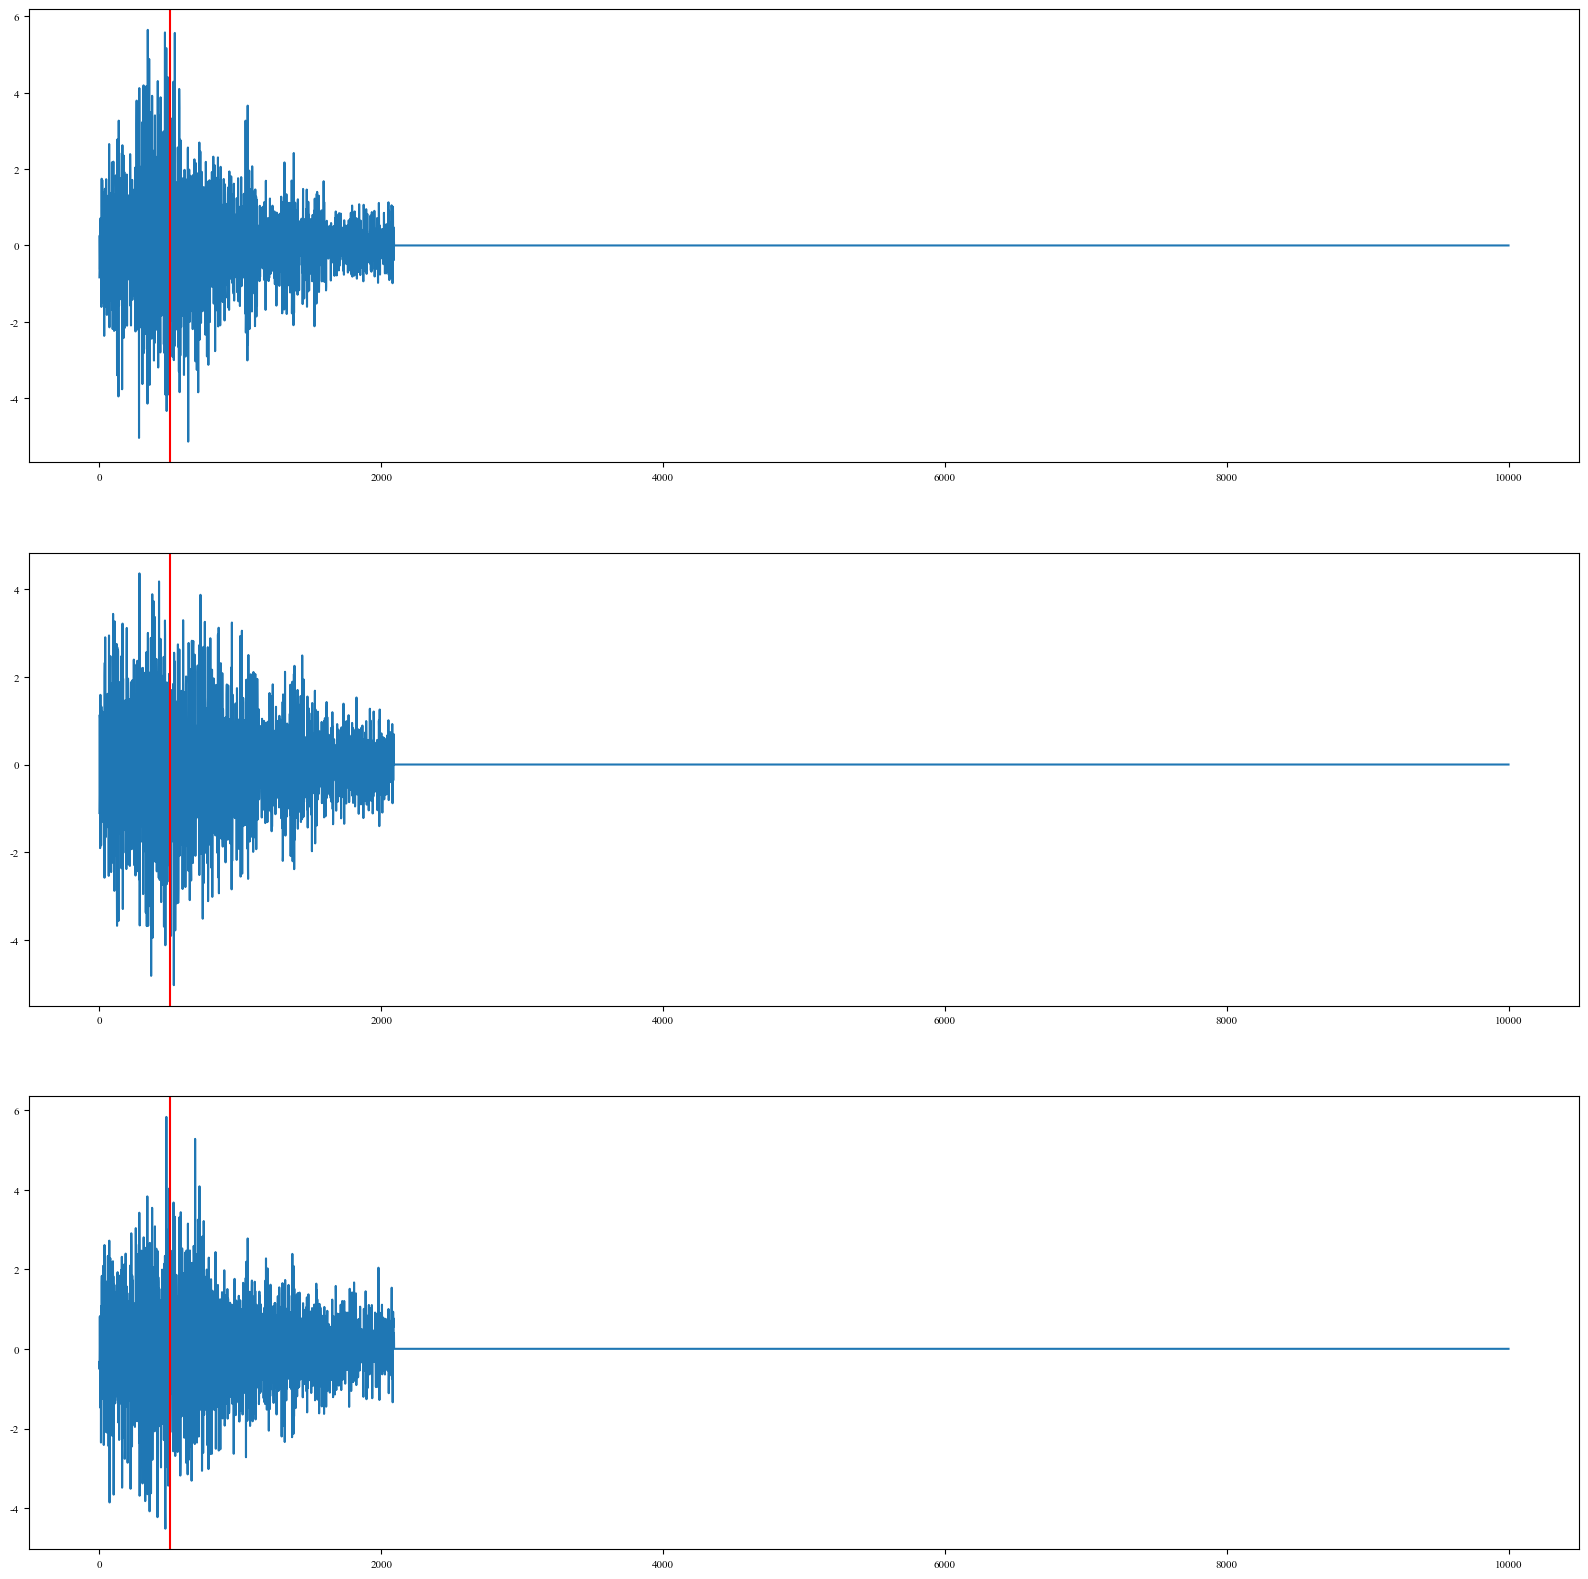

In [114]:
fig, axes = plt.subplots(3,1, figsize=(20,20))
axes[0].plot(inputs[0][ibatch,istation,0].cpu().numpy())
axes[0].axvline(x=picks[ibatch,0,istation], c='r')
axes[1].plot(inputs[0][ibatch,istation,1].cpu().numpy())
axes[1].axvline(x=picks[ibatch,0,istation], c='r')
axes[2].plot(inputs[0][ibatch,istation,2].cpu().numpy())
axes[2].axvline(x=picks[ibatch,0,istation], c='r')
plt.show()
plt.close()

In [43]:
picks[ibatch,0]

tensor([ 1632.,  1785.,   500., 10000., 10000., 10000., 10000., 10000., 10000.,
        10000., 10000., 10000., 10000., 10000., 10000., 10000., 10000., 10000.,
        10000., 10000., 10000., 10000., 10000., 10000., 10000.],
       dtype=torch.float64)

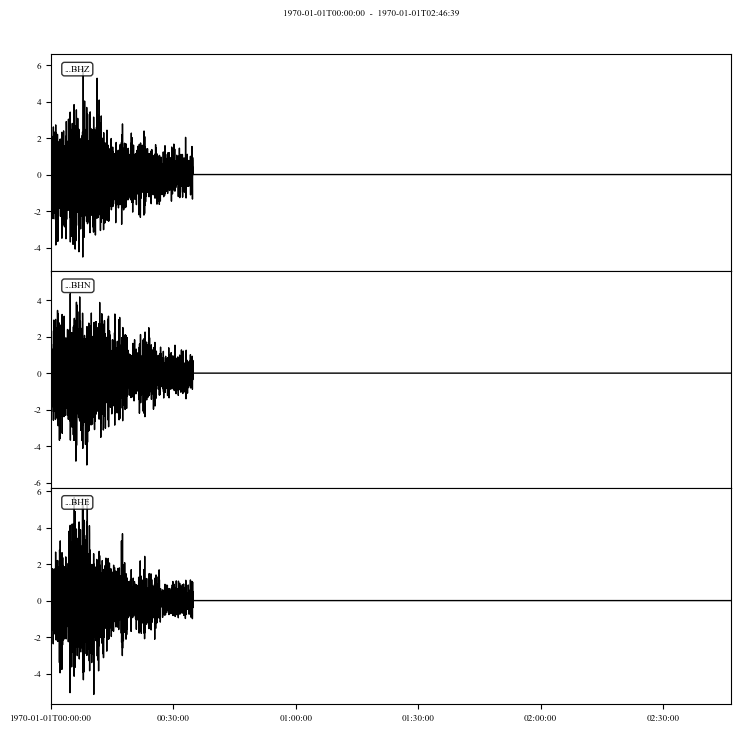

In [46]:
st = obspy.Stream()
st += obspy.Trace(data=inputs[0][ibatch,istation,0].cpu().numpy(), header={'channel':'BHE'})
st += obspy.Trace(data=inputs[0][ibatch,istation,1].cpu().numpy(), header={'channel':'BHN'})
st += obspy.Trace(data=inputs[0][ibatch,istation,2].cpu().numpy(), header={'channel':'BHZ'})
st.plot()
plt.show()
plt.close()

In [121]:
labels[1]

tensor([[[ 4.7839e+01],
         [ 9.7184e-01],
         [ 5.6000e-02]],

        [[ 4.6705e+01],
         [ 1.0319e+00],
         [ 7.1000e-02]],

        [[ 4.7228e+01],
         [ 1.5045e+00],
         [ 1.1100e-01]],

        [[ 4.8996e+01],
         [-8.3063e-01],
         [ 3.8000e-02]],

        [[ 4.8359e+01],
         [ 7.6947e-01],
         [ 3.6700e-01]],

        [[ 5.1924e+01],
         [-2.7443e+00],
         [ 2.0000e-02]],

        [[ 4.9531e+01],
         [-1.8403e+00],
         [ 2.2900e-01]],

        [[ 4.8848e+01],
         [-2.0304e+00],
         [ 3.1000e-02]],

        [[ 4.5115e+01],
         [ 3.4015e+00],
         [ 3.3000e+00]],

        [[ 4.9531e+01],
         [-1.8403e+00],
         [ 2.2900e-01]],

        [[ 4.6785e+01],
         [ 3.7795e+00],
         [ 1.1000e-02]],

        [[ 4.8996e+01],
         [-8.3063e-01],
         [ 3.8000e-02]],

        [[ 4.9577e+01],
         [-1.8514e+00],
         [ 2.3600e-01]],

        [[ 4.8492e+01],
         [ 1.4

In [115]:
models.mixture_density_loss(outputs, labels)

tensor(0.8394, device='cuda:0')

In [115]:
tmpxx = np.random.randint(np.zeros((1,5)),high=np.ones((1,5))*10)
print(tmpxx)
tmpyy = np.random.randint(np.zeros((1,5)),high=np.ones((1,5))*10)
print(tmpyy)

[[1 7 4 3 7]]
[[6 5 1 4 8]]


In [116]:

print((tmpxx>5)*tmpyy)

[[0 5 0 0 8]]


In [119]:

print((tmpxx>5)*tmpyy *((tmpxx>5)*tmpyy<7))

[[0 5 0 0 0]]


In [121]:
xxxx = np.random.rand(1,5,10,3)

In [132]:
idxxx = np.arange(10).reshape(1,1,-1)
cutout = np.expand_dims((tmpxx>5)*tmpyy,-1)

In [136]:
idxxx

array([[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]])

In [138]:
((tmpxx>5)*tmpyy)[:,:,np.newaxis,np.newaxis]

array([[[[0]],

        [[5]],

        [[0]],

        [[0]],

        [[8]]]])

In [134]:
idxxx < cutout

array([[[False, False, False, False, False, False, False, False, False,
         False],
        [ True,  True,  True,  True,  True, False, False, False, False,
         False],
        [False, False, False, False, False, False, False, False, False,
         False],
        [False, False, False, False, False, False, False, False, False,
         False],
        [ True,  True,  True,  True,  True,  True,  True,  True, False,
         False]]])